../../circle_electrode_1.0.csv: potential min/max = 0/0, points = 9600
../../circle_electrode_2.0.csv: potential min/max = 0/0, points = 9600


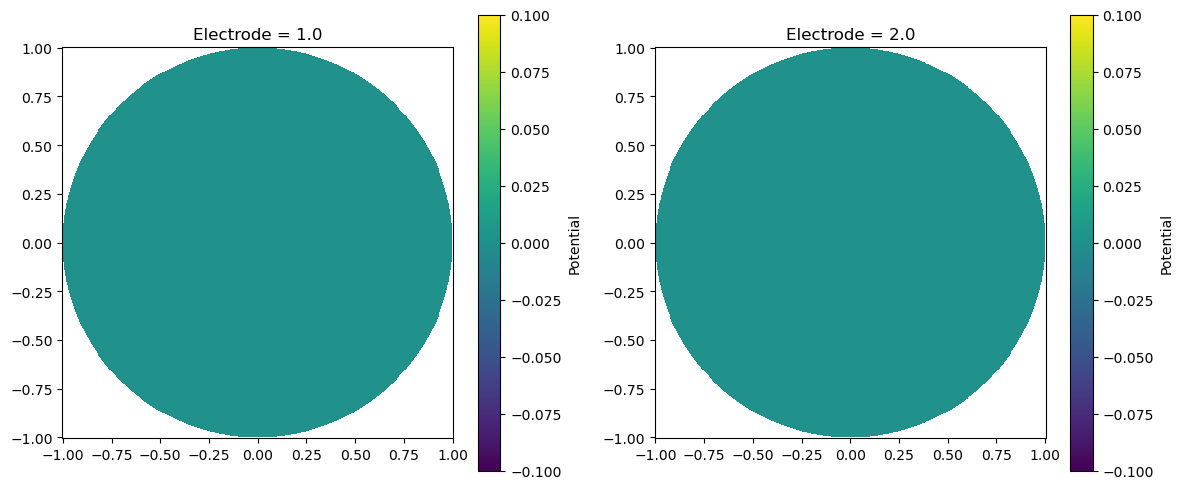

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

def load_and_grid_cartesian(csvfile, radius, N=400):
    df = pd.read_csv(csvfile)
    if df.empty:
        raise RuntimeError(f"{csvfile} is empty")
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()
    pot = df["potential"].to_numpy()

    # print basic diagnostics
    print(f"{csvfile}: potential min/max = {pot.min():.6g}/{pot.max():.6g}, points = {len(pot)}")

    # create regular Cartesian grid covering the circle
    xi = np.linspace(-radius, radius, N)
    yi = np.linspace(-radius, radius, N)
    XI, YI = np.meshgrid(xi, yi, indexing="xy")

    # interpolate using nearest (robust for scattered boundary/inside sampling)
    points = np.vstack([x, y]).T
    grid_pot = griddata(points, pot, (XI, YI), method="nearest")

    # mask outside the circle
    R = np.sqrt(XI**2 + YI**2)
    grid_pot[R > radius] = np.nan

    return XI, YI, grid_pot

def plot_cartesian(csvfile, ax, title):
    radius = 1.0  # must match C++ usage
    X, Y, grid = load_and_grid_cartesian(csvfile, radius)
    im = ax.pcolormesh(X, Y, grid, shading="auto")
    ax.set_aspect("equal", "box")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Potential")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plot_cartesian("../../circle_electrode_1.0.csv", axs[0], "Electrode = 1.0")
plot_cartesian("../../circle_electrode_2.0.csv", axs[1], "Electrode = 2.0")
plt.tight_layout()
plt.show()
